In [11]:
# --- SETUP: run this first in any new notebook ---
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

DATA_PATH = '/content/drive/MyDrive/data-projects/esg-data/'

esg = pd.read_csv(DATA_PATH + 'ESGData.csv')
country_info = pd.read_csv(DATA_PATH + 'ESGCountry.csv')
#gdp_data = pd.read_csv(DATA_PATH + 'GDP by Country.csv', skiprows=4)

energy_mix = pd.read_csv(DATA_PATH + 'World Energy Consumption.csv')

real_countries = country_info[country_info["Region"].notna()]["Country Code"]
year_columns = [str(y) for y in range(1990, 2015)]

print("Setup complete. Data loaded:", esg.shape, country_info.shape, energy_mix.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete. Data loaded: (16013, 67) (239, 31) (22012, 129)


In [13]:
countries_of_interest = ["Chile", "Argentina", "Brazil", "Colombia", "Peru"]

# For the trend-over-time chart
renewables_trend = energy_mix[energy_mix["country"].isin(countries_of_interest)][
    ["country", "year", "renewables_share_elec"]
]
renewables_trend = renewables_trend[renewables_trend["year"] >= 1990]

# For the source-mix stacked bar chart
source_cols = ["country", "year", "hydro_share_elec", "solar_share_elec", "wind_share_elec",
               "coal_share_elec", "gas_share_elec", "oil_share_elec", "nuclear_share_elec"]
energy_5 = energy_mix[energy_mix["country"].isin(countries_of_interest)][source_cols]

print("Filtering complete:", renewables_trend.shape, energy_5.shape)

Filtering complete: (165, 3) (615, 9)


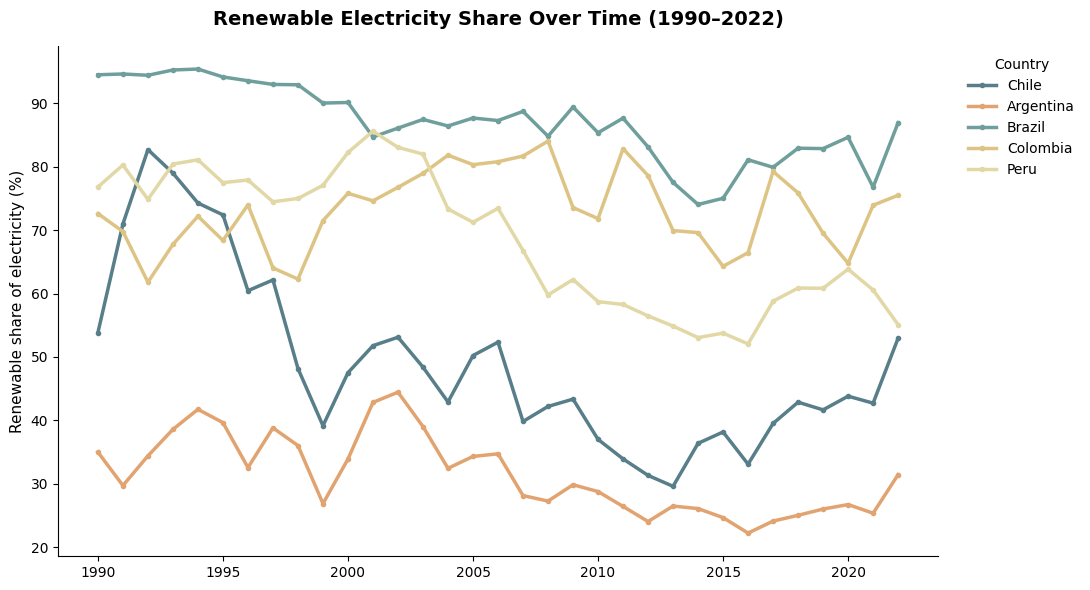

In [17]:
import matplotlib.pyplot as plt

country_colors = {
    "Chile": "#577E89",
    "Argentina": "#E1A36F",
    "Brazil": "#6F9F9C",
    "Colombia": "#DEC484",
    "Peru": "#E2D8A5",
}

fig, ax = plt.subplots(figsize=(11,6))
for country in countries_of_interest:
    subset = renewables_trend[renewables_trend["country"] == country]
    ax.plot(subset["year"], subset["renewables_share_elec"],
            marker="o", markersize=3, linewidth=2.5, label=country, color=country_colors[country])

ax.set_title("Renewable Electricity Share Over Time (1990–2022)", fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("Renewable share of electricity (%)", fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend moved outside the plot area, to the right
ax.legend(title="Country", frameon=False, fontsize=10,
          bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig("latam_renewables_trend_1990_2022.png", bbox_inches="tight", dpi=150)
plt.show()

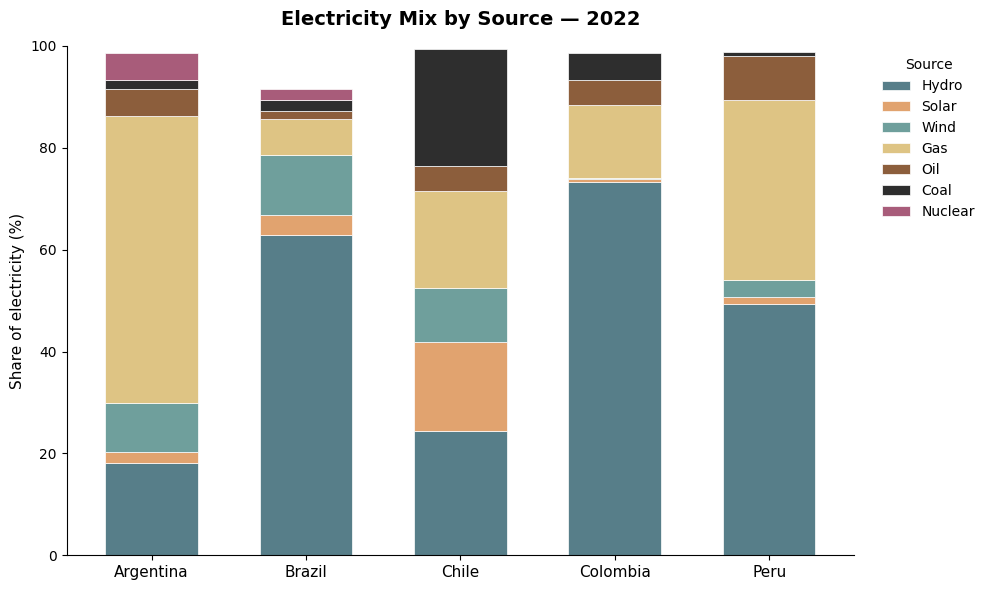

In [20]:
sources = ["hydro_share_elec", "solar_share_elec", "wind_share_elec",
           "gas_share_elec", "oil_share_elec", "coal_share_elec", "nuclear_share_elec"]

colors = {
    "hydro_share_elec": "#577E89",     # Smalt Blue
    "solar_share_elec": "#E1A36F",     # Harvest Gold
    "wind_share_elec":  "#6F9F9C",     # Sea Nymph
    "gas_share_elec":   "#DEC484",     # Calico
    "oil_share_elec":   "#8C5E3C",     # deep brown
    "coal_share_elec":  "#2E2E2E",     # near-black
    "nuclear_share_elec": "#A85C7A",   # muted plum
}

labels = {
    "hydro_share_elec": "Hydro", "solar_share_elec": "Solar", "wind_share_elec": "Wind",
    "gas_share_elec": "Gas", "oil_share_elec": "Oil", "coal_share_elec": "Coal",
    "nuclear_share_elec": "Nuclear",
}

latest_year = energy_5["year"].max()
latest = energy_5[energy_5["year"] == latest_year].sort_values("country").set_index("country")

fig, ax = plt.subplots(figsize=(10,6))
latest[sources].plot(kind="bar", stacked=True, ax=ax, color=[colors[s] for s in sources],
                       width=0.6, edgecolor="white", linewidth=0.5)

ax.set_title(f"Electricity Mix by Source — {latest_year}", fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("Share of electricity (%)", fontsize=11)
ax.set_xlabel("")
ax.set_xticklabels(latest.index, rotation=0, fontsize=11)
ax.set_ylim(0, 100)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, [labels[s] for s in sources], title="Source",
          bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, fontsize=10)

plt.tight_layout()
plt.savefig("latam_electricity_mix_2022.png", bbox_inches="tight", dpi=150)
plt.show()

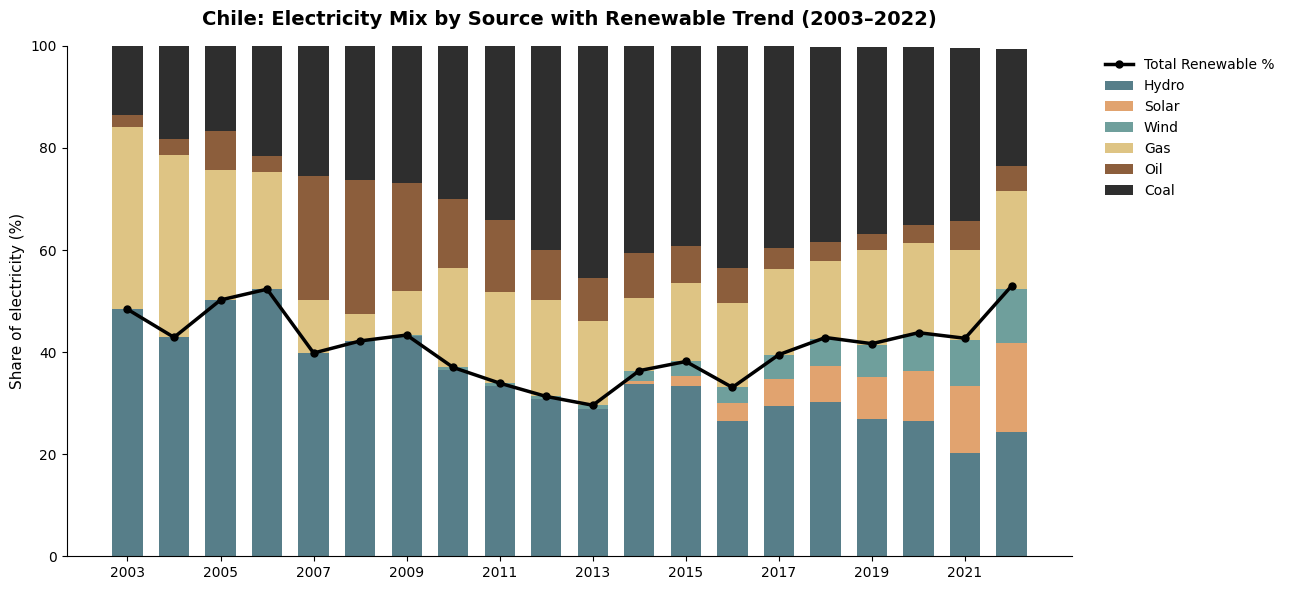

In [23]:
chile_energy = energy_mix[energy_mix["country"] == "Chile"]
chile_energy = chile_energy[chile_energy["year"] >= 2003].sort_values("year")

sources = ["hydro_share_elec", "solar_share_elec", "wind_share_elec",
           "gas_share_elec", "oil_share_elec", "coal_share_elec"]  # nuclear excluded (all zero for Chile)

colors = {
    "hydro_share_elec": "#577E89", "solar_share_elec": "#E1A36F", "wind_share_elec": "#6F9F9C",
    "gas_share_elec": "#DEC484", "oil_share_elec": "#8C5E3C", "coal_share_elec": "#2E2E2E",
}
labels = {
    "hydro_share_elec": "Hydro", "solar_share_elec": "Solar", "wind_share_elec": "Wind",
    "gas_share_elec": "Gas", "oil_share_elec": "Oil", "coal_share_elec": "Coal",
}

fig, ax = plt.subplots(figsize=(13,6))

# Stacked bars: build up each segment on top of the previous one
bottom = [0] * len(chile_energy)
for s in sources:
    ax.bar(chile_energy["year"], chile_energy[s], bottom=bottom,
           color=colors[s], label=labels[s], width=0.65)
    bottom = [b + v for b, v in zip(bottom, chile_energy[s])]

# Overlay line: total renewable share (hydro+solar+wind), on the same axis
renewable_total = chile_energy["renewables_share_elec"]
ax.plot(chile_energy["year"], renewable_total, color="black", linewidth=2.5,
        marker="o", markersize=5, label="Total Renewable %", zorder=5)

ax.set_title("Chile: Electricity Mix by Source with Renewable Trend (2003–2022)",
             fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("Share of electricity (%)", fontsize=11)
ax.set_xticks(range(2003, 2023, 2))
ax.set_ylim(0, 100)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, fontsize=10, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig("chile_electricity_mix_trend.png", bbox_inches="tight", dpi=150)
plt.show()